In [2]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
weights = models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = models.detection.fasterrcnn_resnet50_fpn(weights=weights)

model.eval()
image_path = "../../datasets/object_detection/image2.jpg"

image = Image.open(image_path).convert("RGB")
transform = transforms.ToTensor()

image_tensor = transform(image)

In [7]:
with torch.no_grad():
    prediction = model([image_tensor])[0]
print("Number of detected objects:", len(prediction["boxes"]))
COCO_INSTANCE_CATEGORY_NAMES = [
'__background__','person','bicycle','car','motorcycle','airplane','bus',
'train','truck','boat','traffic light','fire hydrant','N/A','stop sign',
'parking meter','bench','bird','cat','dog','horse','sheep','cow',
'elephant','bear','zebra','giraffe','N/A','backpack','umbrella','N/A',
'N/A','handbag','tie','suitcase','frisbee','skis','snowboard',
'sports ball','kite','baseball bat','baseball glove','skateboard',
'surfboard','tennis racket','bottle','N/A','wine glass','cup','fork',
'knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
'carrot','hot dog','pizza','donut','cake','chair','couch',
'potted plant','bed','N/A','dining table','N/A','N/A','toilet',
'N/A','tv','laptop','mouse','remote','keyboard','cell phone',
'microwave','oven','toaster','sink','refrigerator','N/A','book',
'clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

count = 0

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]
):

    if score > 0.8:

        count += 1

        print(f"\nObject {count}")

        print("Bounding Box:", box.tolist())
        print("Label:", COCO_INSTANCE_CATEGORY_NAMES[label.item()])
        print("Confidence:", round(score.item(), 3))

Number of detected objects: 95

Object 1
Bounding Box: [26.66864013671875, 90.21250915527344, 82.50173950195312, 119.48976135253906]
Label: car
Confidence: 0.996

Object 2
Bounding Box: [246.35952758789062, 80.93762969970703, 304.5460205078125, 111.82077026367188]
Label: car
Confidence: 0.995

Object 3
Bounding Box: [380.41802978515625, 55.93702697753906, 432.3138427734375, 84.91913604736328]
Label: car
Confidence: 0.995

Object 4
Bounding Box: [179.8262939453125, 68.94618225097656, 235.7172088623047, 94.91915130615234]
Label: car
Confidence: 0.991

Object 5
Bounding Box: [318.7962341308594, 148.24595642089844, 394.8150634765625, 200.23785400390625]
Label: car
Confidence: 0.99

Object 6
Bounding Box: [392.9256286621094, 137.30538940429688, 459.57965087890625, 178.4427947998047]
Label: car
Confidence: 0.99

Object 7
Bounding Box: [417.3627624511719, 54.29296875, 461.8005676269531, 78.34929656982422]
Label: car
Confidence: 0.989

Object 8
Bounding Box: [0.17768262326717377, 37.7537231445

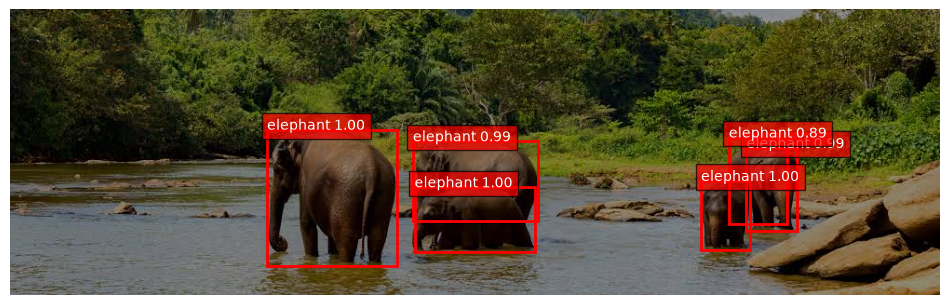

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(image)

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]
):

    if score > 0.8:

        xmin, ymin, xmax, ymax = box

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin,
            f"{COCO_INSTANCE_CATEGORY_NAMES[label.item()]} {score:.2f}",
            fontsize=10,
            color="white",
            bbox=dict(facecolor="red", alpha=0.7)
        )

plt.axis("off")
plt.show()